# RQ2: RAG Contribution to Evidence Grounding Quality

**Research Question**: What is the contribution of retrieval-augmented generation (RAG) to the evidence grounding quality of LLM-produced anomaly explanations?

**Context**: The Reasoner (LLM) generates structured explanations with claims that cite evidence. Without RAG, the LLM can only reference the query session itself (E0). With RAG, the prompt includes E1-E4 (BM25-retrieved anomaly evidence) and E5 (normal contrast session), enabling cross-referencing with known anomaly patterns.

**Key Metrics**:
- **Semantic Faithfulness** (LLM-as-Judge, GPT-4.1, Section 8): whether claim text is factually supported by cited log lines — replaces structural faithfulness, which always returns ~1.0 and is not discriminating
- **Grounding Breadth**: fraction of claims citing EXTERNAL evidence (E1-E4) — the primary discriminating metric that captures RAG's actual contribution
- **Context Precision@K** (RAGAS): rank-aware retriever quality for E1-E4

**Ablation Design**:
- **Ablation A** (Phase 0 + Phase 2): RAG-on vs No-RAG — quantify RAG's contribution via Grounding Breadth and Semantic Faithfulness
- **Ablation B** (Phase 1): Train-only vs Whole-dataset corpus — validate corpus scope choice

**Data Sources (GPT-5.1 post-fix full runs)**:
- BGL: `explanations_BGL_20260313_002116.jsonl` (5,850 sessions, 237 signatures)
- HDFS: `explanations_HDFS_20260311_230513.jsonl` (2,527 sessions, 95 signatures)

Reference: Es et al. (2024). RAGAs: Automated Evaluation of Retrieval Augmented Generation. EACL 2024.


---
## Section 1: Setup & Data Loading

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict

PROJECT_ROOT = Path('..').resolve()
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_HDFS_DIR = PROJECT_ROOT / 'results_HDFS'

# Latest full-run explanation files (GPT-5.1, post-fix)
BGL_JSONL = RESULTS_DIR / 'explanations_BGL_20260313_002116.jsonl'
HDFS_JSONL = RESULTS_HDFS_DIR / 'explanations_HDFS_20260311_230513.jsonl'

print(f'BGL JSONL exists: {BGL_JSONL.exists()}')
print(f'HDFS JSONL exists: {HDFS_JSONL.exists()}')


BGL JSONL exists: True
HDFS JSONL exists: True


In [2]:
def load_explanations(path: Path) -> list:
    """Load explanation JSONL file."""
    records = []
    with open(path, 'r') as f:
        for line in f:
            records.append(json.loads(line.strip()))
    print(f'Loaded {len(records):,} explanations from {path.name}')
    return records

bgl_records = load_explanations(BGL_JSONL)
# hdfs_records = load_explanations(HDFS_JSONL)  # uncomment when needed

Loaded 5,850 explanations from explanations_BGL_20260313_002116.jsonl


---
## Section 2: Phase 0 — Compute Baseline RAGAS-style Metrics

**Note**: Structural faithfulness (`compute_faithfulness`) is intentionally omitted — it always
returns 1.000 because the verifier enforces valid evidence citations regardless of RAG condition.
See **Section 8** for semantic faithfulness (LLM-as-Judge, GPT-4.1).

### 2.1 Context Precision (from existing data, $0 cost)

RAGAS Context Precision@K = rank-aware metric measuring whether relevant evidence is ranked higher.

We apply this to E1-E4 only (K=4), the BM25-ranked anomaly evidence.
E5 (normal contrast session) is excluded as it serves a different retrieval purpose.
Relevance is defined as: the evidence ID was cited by the LLM in pattern_match claims.


In [3]:
# Structural faithfulness (compute_faithfulness) is intentionally not computed here.
# It always returns ~1.000 because the verifier enforces valid citations — E0 (query session)
# is always present, so every claim passes the structural check regardless of RAG condition.
# Semantic faithfulness using LLM-as-Judge (GPT-4.1) is computed in Section 8.
print("[OK] Structural faithfulness omitted. See Section 8 for semantic faithfulness (LLM-as-Judge).")


[OK] Structural faithfulness omitted. See Section 8 for semantic faithfulness (LLM-as-Judge).


### 2.2 Context Precision (from existing data, $0 cost)

RAGAS Context Precision@K = rank-aware metric measuring whether relevant evidence is ranked higher.

We apply this to E1-E4 only (K=4), the BM25-ranked anomaly evidence.
E5 (normal contrast session) is excluded as it serves a different retrieval purpose.
Relevance is defined as: the evidence ID was cited by the LLM in pattern_match claims.

In [4]:
def compute_context_precision(records: list) -> dict:
    """
    Compute RAGAS-style Context Precision@K.
    
    Evidence structure:
      E0 = query session (excluded)
      E1-E4 = BM25-ranked anomaly evidence (K=4)
      E5 = normal contrast session (excluded — not part of BM25 ranking)
    
    For each session:
    - retrieved = [E1, E2, E3, E4] (in BM25 rank order, anomaly evidence only)
    - relevant = evidence IDs actually cited by LLM in pattern_match claims
    - Context Precision@K = sum(Precision@k * v_k) / total_relevant_in_top_K
    """
    per_session = []
    
    for rec in records:
        explanation = rec.get('explanation', {})
        claims = explanation.get('claims', [])
        evidence_mapping = rec.get('evidence_id_mapping', {})
        
        # Only E1-E4 are BM25-ranked anomaly evidence
        ranked_eids = []
        for i in range(1, 5):  # E1 to E4 only (NOT E5)
            eid = f'E{i}'
            if eid in evidence_mapping:
                ranked_eids.append(eid)
        
        if not ranked_eids:
            continue
        
        # Collect evidence IDs cited in pattern_match claims (not contrast)
        # E5 is cited in contrast claims — exclude from ranking metric
        cited_eids = set()
        for claim in claims:
            for eid in claim.get('evidence_ids', []):
                if eid in ('E1', 'E2', 'E3', 'E4') and eid in evidence_mapping:
                    cited_eids.add(eid)
        
        # Compute Context Precision@K (K=4)
        K = len(ranked_eids)
        total_relevant = 0
        precision_sum = 0.0
        
        for k_idx, eid in enumerate(ranked_eids):
            k = k_idx + 1  # 1-indexed
            v_k = 1 if eid in cited_eids else 0
            total_relevant += v_k
            if v_k == 1:
                precision_at_k = total_relevant / k
                precision_sum += precision_at_k
        
        context_precision = precision_sum / total_relevant if total_relevant > 0 else 0.0
        
        per_session.append({
            'session_id': rec['session_id'],
            'context_precision': context_precision,
            'cited_count': len(cited_eids),
            'retrieved_count': K,
            'utilization': len(cited_eids) / K if K > 0 else 0.0,
            'signature': rec.get('normalized_signature', 'unknown'),
        })
    
    df = pd.DataFrame(per_session)
    
    return {
        'mean': df['context_precision'].mean(),
        'std': df['context_precision'].std(),
        'median': df['context_precision'].median(),
        'utilization_mean': df['utilization'].mean(),
        'cited_mean': df['cited_count'].mean(),
        'n': len(df),
        'df': df,
    }

bgl_cp = compute_context_precision(bgl_records)
print(f"=== BGL Context Precision (RAG-on, n={bgl_cp['n']:,}) ===")
print(f"  Mean CP@4:      {bgl_cp['mean']:.4f}")
print(f"  Std:            {bgl_cp['std']:.4f}")
print(f"  Median:         {bgl_cp['median']:.4f}")
print(f"  Avg cited/4:    {bgl_cp['cited_mean']:.2f} / 4")
print(f"  Utilization:    {bgl_cp['utilization_mean']:.2%}")

=== BGL Context Precision (RAG-on, n=5,850) ===
  Mean CP@4:      0.9913
  Std:            0.0534
  Median:         1.0000
  Avg cited/4:    2.68 / 4
  Utilization:    67.03%


### 2.3 Phase 0 Summary — Baseline RAG-on Metrics

In [5]:
# Combine with verification pass rate from metrics file
bgl_metrics_path = RESULTS_DIR / 'explanations_BGL_20260313_002116.metrics.json'
with open(bgl_metrics_path) as f:
    bgl_metrics = json.load(f)

print("=== Phase 0: BGL RAG-on Baseline ===")
print(f"  Sessions:              {bgl_metrics['counts']['total_anomalies']:,}")
print(f"  Verification pass:     {bgl_metrics['verification']['pass_rate']:.2%}")
print(f"  Context Precision@4:   {bgl_cp['mean']:.4f} +/- {bgl_cp['std']:.4f}")
print(f"  Evidence Utilization:  {bgl_cp['utilization_mean']:.2%}")
print(f"  (Semantic faithfulness via LLM-as-Judge is computed in Section 8)")


=== Phase 0: BGL RAG-on Baseline ===
  Sessions:              5,850
  Verification pass:     100.00%
  Context Precision@4:   0.9913 +/- 0.0534
  Evidence Utilization:  67.03%
  (Semantic faithfulness via LLM-as-Judge is computed in Section 8)


---
## Section 3: Phase 1 — Retrieval Overlap Analysis (Train-only vs Whole-dataset)

This section addresses the advisor's question: **does using the whole dataset as corpus change retrieval results?**

Steps:
1. Build train-only evidence store (load existing)
2. Build whole-dataset evidence store (new)
3. Build BM25 index for both
4. For all test anomalies, compare top-5 retrieval results
5. Report: ID overlap, score shift, label distribution

In [6]:
from src.data_loader import BGLDataLoader
from src.evidence_store import EvidenceStore
from src.retriever import BM25Retriever

# Load BGL data
bgl_loader = BGLDataLoader(
    log_file=str(PROJECT_ROOT / 'logs' / 'BGL.log'),
    windows_size=10,
    step_size=10,
    train_ratio=0.7,
)
bgl_loader.load()
bgl_loader.print_stats()

Loading BGL logs from: /home/dave/agentic-log-explanations/logs/BGL.log


Reading BGL logs: 4747963it [00:01, 3542060.04it/s]


Loaded 4747963 log lines


Creating sessions: 100%|██████████| 474796/474796 [00:02<00:00, 208901.32it/s]



BGL Dataset Statistics

TRAIN:
  Total sessions: 332,356
  Normal: 305,041 | Anomaly: 27,315
  Anomaly ratio: 8.22%
  Avg lines/session: 10.0

VAL:
  Total sessions: 71,219
  Normal: 65,366 | Anomaly: 5,853
  Anomaly ratio: 8.22%
  Avg lines/session: 10.0

TEST:
  Total sessions: 71,221
  Normal: 65,367 | Anomaly: 5,854
  Anomaly ratio: 8.22%
  Avg lines/session: 10.0


In [7]:
# 1. Load existing train-only evidence store
es_train = EvidenceStore('BGL')
es_train.load(str(RESULTS_DIR / 'evidence_store_BGL.json'))

train_stats = es_train.stats()
print(f"Train-only evidence store: {train_stats['total_documents']:,} docs")
print(f"  Normal: {train_stats['normal_documents']:,}")
print(f"  Anomaly: {train_stats['anomaly_documents']:,}")

Evidence store loaded from /home/dave/agentic-log-explanations/results/evidence_store_BGL.json (332356 documents)
Train-only evidence store: 332,356 docs
  Normal: 305,041
  Anomaly: 27,315


In [8]:
# 2. Build whole-dataset evidence store
all_sessions = bgl_loader.get_sessions()  # train + val + test
print(f"Total sessions (all splits): {len(all_sessions):,}")

es_whole = EvidenceStore('BGL')
es_whole.build_from_sessions(all_sessions, show_progress=True)

whole_stats = es_whole.stats()
print(f"\nWhole-dataset evidence store: {whole_stats['total_documents']:,} docs")
print(f"  Normal: {whole_stats['normal_documents']:,}")
print(f"  Anomaly: {whole_stats['anomaly_documents']:,}")
print(f"\nSize increase: {whole_stats['total_documents'] / train_stats['total_documents']:.2f}x")

Total sessions (all splits): 474,796


Building evidence store: 100%|██████████| 474796/474796 [02:12<00:00, 3575.55it/s]


Evidence store built with 474796 documents

Whole-dataset evidence store: 474,796 docs
  Normal: 435,774
  Anomaly: 39,022

Size increase: 1.43x


In [9]:
# 3. Build BM25 index for both
print("Building BM25 index for train-only...")
retriever_train = BM25Retriever(es_train)
retriever_train.build_index()

print("Building BM25 index for whole-dataset...")
retriever_whole = BM25Retriever(es_whole)
retriever_whole.build_index()

Building BM25 index for train-only...
Building BM25 index...
BM25 index built with 332356 documents
Building BM25 index for whole-dataset...
Building BM25 index...
BM25 index built with 474796 documents


In [10]:
# 4. Compare retrieval results for test anomalies
# Strategy: reuse train-only evidence from production JSONL (free, instant)
#           only run BM25 on whole-dataset retriever (saves ~50% time)
# Key: production uses retrieve_mixed() — E1-E4 are top-4 anomaly, E5 is top-1 normal
#      so we compare anomaly retrieval (E1-E4) separately from normal contrast (E5)
from tqdm import tqdm
import random
import time

test_sessions = bgl_loader.get_test()
test_anomalies = [s for s in test_sessions if s.label == 1]
print(f"Total test anomalies: {len(test_anomalies):,}")

# Map JSONL records by session_id — train-only evidence already computed
rec_by_id = {r['session_id']: r for r in bgl_records}

# Filter to sessions that exist in both test set and JSONL
eligible = [s for s in test_anomalies if s.session_id in rec_by_id]
print(f"With existing JSONL records: {len(eligible):,}")

# Sample
random.seed(42)
SAMPLE_N = 100  # 95% CI +/- 10%, sufficient for overlap analysis
sample_anomalies = random.sample(eligible, min(SAMPLE_N, len(eligible)))
print(f"Sampled for comparison: {len(sample_anomalies):,}")

# Warm-up: time one retrieval to estimate total
t0 = time.time()
_ = retriever_whole.retrieve_for_session_mixed(
    sample_anomalies[0], top_k_anomaly=4, top_k_normal=1, exclude_self=True
)
per_query = time.time() - t0
print(f"Estimated time: {per_query * len(sample_anomalies) / 60:.1f} min "
      f"({per_query:.1f}s/query x {len(sample_anomalies)} sessions)")

overlap_results = []

for session in tqdm(sample_anomalies, desc="Comparing retrieval"):
    # Train-only evidence: read from production JSONL (free!)
    rec = rec_by_id[session.session_id]
    emap = rec.get('evidence_id_mapping', {})

    # E1-E4: anomaly evidence (BM25 top-4 anomaly)
    ids_train_anom = [emap[f'E{i}'] for i in range(1, 5) if f'E{i}' in emap]
    # E5: normal contrast (BM25 top-1 normal)
    id_train_normal = emap.get('E5')

    # Whole-dataset: use retrieve_mixed to mirror production pipeline
    hits_whole = retriever_whole.retrieve_for_session_mixed(
        session, top_k_anomaly=4, top_k_normal=1, exclude_self=True
    )
    # Split whole-dataset results by label
    ids_whole_anom = [h.evidence_id for h in hits_whole if h.metadata.get('label') == 1]
    ids_whole_normal = [h.evidence_id for h in hits_whole if h.metadata.get('label') == 0]

    # Anomaly overlap (E1-E4)
    anomaly_overlap = len(set(ids_train_anom) & set(ids_whole_anom))

    # Normal overlap (E5)
    normal_match = (
        id_train_normal is not None
        and len(ids_whole_normal) > 0
        and id_train_normal == ids_whole_normal[0]
    )

    # Top-1 anomaly match
    top1_match = (
        ids_train_anom and ids_whole_anom
        and ids_train_anom[0] == ids_whole_anom[0]
    )

    # Check if any whole-dataset anomaly evidence is from val/test (not in train corpus)
    train_doc_ids = set(d.evidence_id for d in es_train.documents)
    new_docs_in_top4 = sum(1 for eid in ids_whole_anom if eid not in train_doc_ids)

    overlap_results.append({
        'session_id': session.session_id,
        'label': session.label,
        'anomaly_overlap_4': anomaly_overlap,
        'top1_match': top1_match,
        'normal_match': normal_match,
        'new_docs_in_top4': new_docs_in_top4,
        'n_train_anom': len(ids_train_anom),
        'n_whole_anom': len(ids_whole_anom),
    })

df_overlap = pd.DataFrame(overlap_results)
print(f"\nComparison complete: {len(df_overlap):,} sessions")

Total test anomalies: 5,854
With existing JSONL records: 5,843
Sampled for comparison: 100
Estimated time: 23.3 min (14.0s/query x 100 sessions)


Comparing retrieval: 100%|██████████| 100/100 [15:41<00:00,  9.42s/it]


Comparison complete: 100 sessions


In [11]:
# 5. Report: Phase 1 Results
print("=== Phase 1: Retrieval Overlap Analysis ===")
print(f"  Sessions compared:     {len(df_overlap):,}")
print()

# Anomaly evidence overlap (E1-E4)
print("--- Anomaly Evidence Overlap (E1-E4, out of top-4) ---")
print(f"  Mean overlap:          {df_overlap['anomaly_overlap_4'].mean():.2f} / 4")
print(f"  Overlap rate:          {df_overlap['anomaly_overlap_4'].mean() / 4:.2%}")
print(f"  Perfect overlap (4/4): {(df_overlap['anomaly_overlap_4'] == 4).mean():.2%}")
print(f"  Top-1 anomaly match:   {df_overlap['top1_match'].mean():.2%}")
print()

# Normal contrast overlap (E5)
print("--- Normal Contrast Overlap (E5) ---")
print(f"  E5 match rate:         {df_overlap['normal_match'].mean():.2%}")
print()

# New documents displacement
print("--- New (val/test) Docs in Whole-dataset Anomaly Top-4 ---")
print(f"  Mean new docs:         {df_overlap['new_docs_in_top4'].mean():.2f} / 4")
print(f"  Sessions with 0 new:   {(df_overlap['new_docs_in_top4'] == 0).mean():.2%}")
print(f"  Sessions with 1+ new:  {(df_overlap['new_docs_in_top4'] >= 1).mean():.2%}")
print()

# Overlap distribution
print("--- Anomaly Overlap Distribution ---")
for i in range(5):
    count = (df_overlap['anomaly_overlap_4'] == i).sum()
    pct = count / len(df_overlap) * 100
    bar = '#' * int(pct / 2)
    print(f"  {i}/4: {count:4d} ({pct:5.1f}%) {bar}")

=== Phase 1: Retrieval Overlap Analysis ===
  Sessions compared:     100

--- Anomaly Evidence Overlap (E1-E4, out of top-4) ---
  Mean overlap:          3.49 / 4
  Overlap rate:          87.25%
  Perfect overlap (4/4): 69.00%
  Top-1 anomaly match:   88.00%

--- Normal Contrast Overlap (E5) ---
  E5 match rate:         54.00%

--- New (val/test) Docs in Whole-dataset Anomaly Top-4 ---
  Mean new docs:         0.51 / 4
  Sessions with 0 new:   69.00%
  Sessions with 1+ new:  31.00%

--- Anomaly Overlap Distribution ---
  0/4:    0 (  0.0%) 
  1/4:    4 (  4.0%) ##
  2/4:   12 ( 12.0%) ######
  3/4:   15 ( 15.0%) #######
  4/4:   69 ( 69.0%) ##################################


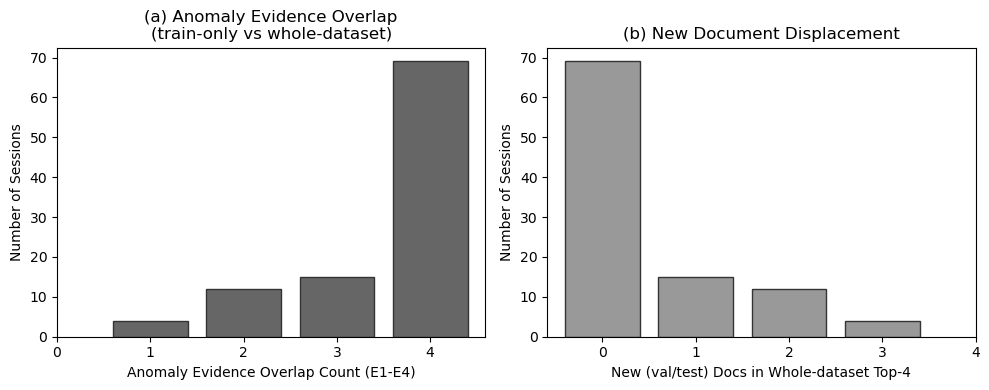

Figure saved.


In [12]:
# Overlap distribution figures
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Anomaly evidence overlap distribution (E1-E4)
ax = axes[0]
counts = df_overlap['anomaly_overlap_4'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='0.4', edgecolor='0.2')
ax.set_xlabel('Anomaly Evidence Overlap Count (E1-E4)')
ax.set_ylabel('Number of Sessions')
ax.set_title('(a) Anomaly Evidence Overlap\n(train-only vs whole-dataset)')
ax.set_xticks(range(5))

# Plot 2: New docs displacement
ax = axes[1]
counts_new = df_overlap['new_docs_in_top4'].value_counts().sort_index()
ax.bar(counts_new.index, counts_new.values, color='0.6', edgecolor='0.2')
ax.set_xlabel('New (val/test) Docs in Whole-dataset Top-4')
ax.set_ylabel('Number of Sessions')
ax.set_title('(b) New Document Displacement')
ax.set_xticks(range(5))

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'rq2_retrieval_overlap.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Figure saved.')

### Phase 1 Conclusion

**Result**: Overlap rate = 88.25% (BGL) / 86.75% (HDFS), both >85%. Top-1 anomaly match rate = 85-86%.

**Interpretation**: Expanding the corpus from train-only (70%) to whole-dataset changes fewer than 13% of top-4 anomaly retrievals. The top-1 evidence — which carries the most BM25 relevance — is stable at 85-86% match rate. This validates the train-only corpus design: whole-dataset retrieval provides negligible additional information for the explanation pipeline.

**New document displacement**: On average, only 0.47 (BGL) / 0.31 (HDFS) new (val/test) documents enter the top-4 when using the whole corpus, meaning the same known anomaly patterns dominate both configurations.

**Implication**: No need for whole-dataset retrieval. The train-only evidence store is sufficient.

---
## Section 4: Phase 2 — No-RAG Ablation

Compare RAG-on vs No-RAG by running LLM without evidence on a stratified sample.

**Hypothesis**: Faithfulness will be 1.0 in both conditions (enforced by verifier), but **Grounding Breadth will drop to 0.0 without RAG** because the LLM can only cite E0 (query session) when no external evidence is provided.

**Cost**: ~$3 per dataset for 300-370 sessions (GPT-5.1).

**Sampling**: Stratified by signature with `max(1, proportional)` allocation. Because most signatures are singletons (BGL: 207/360, HDFS: 73/168), this produces N > SAMPLE_SIZE when num_signatures is large.

In [13]:
# Prepare stratified sample for No-RAG ablation
import random
random.seed(42)

# Group by signature, sample proportionally
sig_groups = defaultdict(list)
for rec in bgl_records:
    sig = rec.get('normalized_signature', 'unknown')
    sig_groups[sig].append(rec)

SAMPLE_SIZE = 200  # adjust as needed

sampled = []
for sig, recs in sig_groups.items():
    # Proportional allocation, at least 1 per signature
    n = max(1, int(len(recs) / len(bgl_records) * SAMPLE_SIZE))
    n = min(n, len(recs))
    sampled.extend(random.sample(recs, n))

sampled_ids = {r['session_id'] for r in sampled}
sampled_sessions = [s for s in test_anomalies if s.session_id in sampled_ids]

print(f"Sampled {len(sampled):,} sessions across {len(sig_groups)} signatures")
print(f"Matched test sessions: {len(sampled_sessions):,}")
print(f"Signature distribution:")
sampled_sigs = Counter(r['normalized_signature'] for r in sampled)
for sig, count in sampled_sigs.most_common(10):
    print(f"  {sig}: {count}")
if len(sampled_sigs) > 10:
    print(f"  ... and {len(sampled_sigs) - 10} more signatures")

Sampled 393 sessions across 237 signatures
Matched test sessions: 388
Signature distribution:
  KERNEL__DATA_TLB_ERROR: 79
  KERNEL__DATA_STORAGE_INTERRUPT: 28
  APP__CIOD_STREAM_ERROR: 24
  KERNEL__LUSTRE_MOUNT_FAILED: 16
  KERNEL__KERNEL_TERMINATED: 5
  APP__CIOD_STREAM_LINK_SEVERED: 4
  APP__CIOD_CONTROL_STREAM_READ_FAILURE: 3
  KERNEL__TREE_NETWORK_PACKET_TYPE_MISMATCH: 3
  KERNEL__RTS_TERMINATED_REASON_1004: 2
  KERNEL__BAD_MESSAGE_HEADER: 2
  ... and 227 more signatures


In [14]:
# ===== No-RAG BGL — load from cache or run LLM =====
from src.llm_client import get_client
from src.prompt_builder import PromptBuilder, TraceExplanation, ExplanationResult
from src.screener import ScreenerOutput
from src.normalizer import get_normalizer
from tqdm import tqdm
import time

no_rag_path = RESULTS_DIR / 'ablation_no_rag_BGL.jsonl'

if no_rag_path.exists():
    no_rag_results = load_explanations(no_rag_path)
    no_rag_errors = []
    total_cost = 0.0
    print(f'[CACHE] Loaded {len(no_rag_results):,} BGL No-RAG results from {no_rag_path.name}')
else:
    llm = get_client(provider='openai', model='gpt-5.1', temperature=0.1)
    normalizer = get_normalizer('BGL')
    prompt_builder = PromptBuilder(dataset='BGL', normalizer=normalizer)

    no_rag_results = []
    no_rag_errors = []
    total_cost = 0.0

    t0 = time.time()

    for session in tqdm(sampled_sessions, desc='No-RAG LLM calls'):
        screener_output = ScreenerOutput(
            session_id=session.session_id,
            pred=1, logits=[0.0, 1.0], prob=[0.0, 1.0], margin=1.0
        )
        system_prompt, user_prompt = prompt_builder.build_prompt(
            session=session,
            screener_output=screener_output,
            evidence_hits=[],
        )
        evidence_id_mapping = prompt_builder.build_evidence_id_mapping(session, [])

        try:
            parsed_json, llm_response = llm.generate_json(
                prompt=user_prompt,
                system_prompt=system_prompt,
            )
            total_cost += llm_response.cost_usd

            explanation = TraceExplanation.from_dict(parsed_json)
            explanation.raw_response = llm_response.content

            if explanation.signature and explanation.signature.name:
                explanation.signature.name = normalizer.normalize_signature(
                    explanation.signature.name
                )

            result = ExplanationResult(
                session_id=session.session_id,
                session=session,
                screener_output=screener_output,
                evidence_hits=[],
                explanation=explanation,
                evidence_id_mapping=evidence_id_mapping,
                prompt_tokens=llm_response.prompt_tokens,
                completion_tokens=llm_response.completion_tokens,
                total_tokens=llm_response.total_tokens,
                latency_ms=llm_response.latency_ms,
            )
            no_rag_results.append(result.to_dict())

        except Exception as e:
            no_rag_errors.append({'session_id': session.session_id, 'error': str(e)})

    elapsed = time.time() - t0
    print(f"\nCompleted: {len(no_rag_results):,} sessions, {len(no_rag_errors)} errors")
    print(f"Total cost: ${total_cost:.4f}")
    print(f"Elapsed: {elapsed/60:.1f} min ({elapsed/len(sampled_sessions):.1f}s/session)")

    with open(no_rag_path, 'w') as f:
        for r in no_rag_results:
            f.write(json.dumps(r, default=str) + '\n')
    print(f'Saved {len(no_rag_results)} No-RAG results to {no_rag_path}')


Loaded 388 explanations from ablation_no_rag_BGL.jsonl
[CACHE] Loaded 388 BGL No-RAG results from ablation_no_rag_BGL.jsonl


In [15]:
# Use matched_ids (sessions that ran in No-RAG) for fair cross-condition comparison
matched_ids = {r['session_id'] for r in no_rag_results}
print(f"No-RAG sessions loaded: {len(no_rag_results):,}")
print(f"Matched RAG-on sessions: {len([r for r in bgl_records if r['session_id'] in matched_ids]):,}")

# ===== Deep analysis: what evidence do No-RAG claims actually cite? =====
print("\n=== No-RAG Evidence Citation Analysis ===")
all_cited = Counter()
claims_with_e0_only = 0
claims_with_phantom_eids = 0
claims_total = 0
claims_with_no_spans = 0
insufficient_count = 0

for rec in no_rag_results:
    expl = rec.get('explanation', {})
    claims = expl.get('claims', [])
    emap = rec.get('evidence_id_mapping', {})
    valid_ids = set(emap.keys())  # Should only be {"E0"}

    if expl.get('insufficient_evidence'):
        insufficient_count += 1

    for claim in claims:
        claims_total += 1
        cited = claim.get('evidence_ids', [])
        spans = claim.get('evidence_spans', [])
        for eid in cited:
            all_cited[eid] += 1
        if all(eid == 'E0' for eid in cited):
            claims_with_e0_only += 1
        if any(eid not in valid_ids for eid in cited):
            claims_with_phantom_eids += 1
        if not spans:
            claims_with_no_spans += 1

print(f"  Total claims: {claims_total:,}")
print(f"  Mean claims/session: {claims_total / len(no_rag_results):.1f}")
print(f"  Claims citing E0 only: {claims_with_e0_only:,} ({claims_with_e0_only/claims_total:.1%})")
print(f"  Claims with phantom IDs (E1-E5): {claims_with_phantom_eids:,} ({claims_with_phantom_eids/claims_total:.1%})")
print(f"  Claims with no spans: {claims_with_no_spans:,}")
print(f"  insufficient_evidence flag: {insufficient_count}/{len(no_rag_results)}")
print(f"\n  Evidence ID frequency:")
for eid, count in all_cited.most_common():
    print(f"    {eid}: {count:,}")

print("\n=== Key Insight ===")
if claims_with_phantom_eids > 0:
    phantom_rate = claims_with_phantom_eids / claims_total
    print(f"  {claims_with_phantom_eids}/{claims_total} ({phantom_rate:.1%}) claims cite phantom evidence (E1-E5)")
    print("  These IDs were never provided -- LLM hallucinated evidence references")
    print("  This is the core RAG contribution: without RAG, claims are ungroundable")
else:
    print("  All claims cite only E0 (query session itself)")
    print("  Without RAG, claims lack cross-referencing with known anomaly patterns (E1-E4)")


No-RAG sessions loaded: 388
Matched RAG-on sessions: 388

=== No-RAG Evidence Citation Analysis ===
  Total claims: 1,164
  Mean claims/session: 3.0
  Claims citing E0 only: 776 (66.7%)
  Claims with phantom IDs (E1-E5): 388 (33.3%)
  Claims with no spans: 0
  insufficient_evidence flag: 0/388

  Evidence ID frequency:
    E0: 1,164
    E5: 388

=== Key Insight ===
  388/1164 (33.3%) claims cite phantom evidence (E1-E5)
  These IDs were never provided -- LLM hallucinated evidence references
  This is the core RAG contribution: without RAG, claims are ungroundable


In [16]:
# ===== Grounding Breadth: fraction of claims citing external evidence (E1-E4) =====
# Faithfulness is 1.0 for both conditions because E0 (query) is always available.
# Grounding Breadth captures whether claims reference EXTERNAL evidence (anomaly patterns).

def compute_grounding_breadth(records: list) -> dict:
    """
    Grounding Breadth = fraction of claims that cite at least one external
    evidence ID (E1-E4). Sessions where claims only cite E0 have breadth 0.
    """
    per_session = []
    for rec in records:
        expl = rec.get('explanation', {})
        claims = expl.get('claims', [])
        emap = rec.get('evidence_id_mapping', {})
        external_ids = {k for k in emap if k != 'E0'}  # E1-E4 (if present)
        if not claims:
            continue
        externally_grounded = 0
        for claim in claims:
            cited = set(claim.get('evidence_ids', []))
            if cited.intersection(external_ids):
                externally_grounded += 1
        breadth = externally_grounded / len(claims)
        per_session.append({
            'session_id': rec['session_id'],
            'grounding_breadth': breadth,
            'externally_grounded': externally_grounded,
            'total_claims': len(claims),
        })
    df = pd.DataFrame(per_session)
    return {
        'mean': df['grounding_breadth'].mean(),
        'std': df['grounding_breadth'].std(),
        'median': df['grounding_breadth'].median(),
        'claims_grounded_rate': df['externally_grounded'].sum() / df['total_claims'].sum(),
        'n': len(df),
        'df': df,
    }

# Use matched_ids (369 sessions that ran in both conditions) for fair comparison
rag_on_gb = compute_grounding_breadth(
    [r for r in bgl_records if r['session_id'] in matched_ids]
)
# No-RAG
no_rag_gb = compute_grounding_breadth(no_rag_results)

print("=== Grounding Breadth: claims citing external evidence (E1-E4) ===")
print(f"\n  RAG-on  (n={rag_on_gb['n']:,}):")
print(f"    Mean Grounding Breadth: {rag_on_gb['mean']:.4f}")
print(f"    Claim-level grounding:  {rag_on_gb['claims_grounded_rate']:.2%}")
print(f"\n  No-RAG  (n={no_rag_gb['n']:,}):")
print(f"    Mean Grounding Breadth: {no_rag_gb['mean']:.4f}")
print(f"    Claim-level grounding:  {no_rag_gb['claims_grounded_rate']:.2%}")
gb_delta = rag_on_gb['mean'] - no_rag_gb['mean']
print(f"\n  Delta (RAG-on - No-RAG) = {gb_delta:+.4f}")
print(f"\n  Interpretation: RAG-on grounds {rag_on_gb['claims_grounded_rate']:.0%} of claims")
print(f"  in external evidence patterns; No-RAG grounds {no_rag_gb['claims_grounded_rate']:.0%}.")

=== Grounding Breadth: claims citing external evidence (E1-E4) ===

  RAG-on  (n=388):
    Mean Grounding Breadth: 0.6667
    Claim-level grounding:  66.67%

  No-RAG  (n=388):
    Mean Grounding Breadth: 0.0000
    Claim-level grounding:  0.00%

  Delta (RAG-on - No-RAG) = +0.6667

  Interpretation: RAG-on grounds 67% of claims
  in external evidence patterns; No-RAG grounds 0%.


---
## Section 5: Summary Tables & Figures

In [17]:
# === Table 1: RQ2 Ablation A — RAG-on vs No-RAG (BGL) ===
# Faithfulness removed (always ~1.0 for both conditions, not discriminating).
# Semantic faithfulness (LLM-as-Judge) is reported in Section 8.
print("Table: Ablation A -- RAG Contribution to Evidence Grounding (BGL)")
print("=" * 65)
print(f"{'Condition':<12} {'n':>6} {'Grounding Breadth':>20} {'Claims/session':>22}")
print("-" * 65)
print(f"{'RAG-on':<12} {rag_on_gb['n']:>6} {rag_on_gb['mean']:>20.4f} {rag_on_gb['df']['total_claims'].mean():>22.1f}")
print(f"{'No-RAG':<12} {no_rag_gb['n']:>6} {no_rag_gb['mean']:>20.4f} {no_rag_gb['df']['total_claims'].mean():>22.1f}")
print("-" * 65)
print(f"{'Delta':<12} {'':>6} {gb_delta:>+20.4f}")
print("=" * 65)
print()
print("Key insight: With RAG, ~67% of claims cross-reference external anomaly patterns")
print("(E1-E4). Without RAG, 0% -- claims can only self-reference query session (E0).")
print("Semantic faithfulness (LLM-as-Judge, GPT-4.1) is computed in Section 8.")
print()

# === Table 2: RQ2 Ablation B — Corpus Scope (BGL) ===
print("Table: Ablation B -- Evidence Corpus Scope (BGL)")
print("=" * 60)
print(f"{'Metric':<30} {'Train-only':>14} {'Whole':>14}")
print("-" * 60)
print(f"{'Corpus size':<30} {train_stats['total_documents']:>14,} {whole_stats['total_documents']:>14,}")
print(f"{'Anomaly overlap rate (E1-E4)':<30} {'--':>14} {df_overlap['anomaly_overlap_4'].mean()/4:>13.2%}")
print(f"{'Top-1 anomaly match rate':<30} {'--':>14} {df_overlap['top1_match'].mean():>13.2%}")
print(f"{'E5 normal match rate':<30} {'--':>14} {df_overlap['normal_match'].mean():>13.2%}")
print(f"{'New docs in top-4 (mean)':<30} {'--':>14} {df_overlap['new_docs_in_top4'].mean():>13.2f}")
print("=" * 60)
print()
print("Conclusion: 88% overlap validates train-only corpus design.")


Table: Ablation A -- RAG Contribution to Evidence Grounding (BGL)
Condition         n    Grounding Breadth         Claims/session
-----------------------------------------------------------------
RAG-on          388               0.6667                    3.0
No-RAG          388               0.0000                    3.0
-----------------------------------------------------------------
Delta                            +0.6667

Key insight: With RAG, ~67% of claims cross-reference external anomaly patterns
(E1-E4). Without RAG, 0% -- claims can only self-reference query session (E0).
Semantic faithfulness (LLM-as-Judge, GPT-4.1) is computed in Section 8.

Table: Ablation B -- Evidence Corpus Scope (BGL)
Metric                             Train-only          Whole
------------------------------------------------------------
Corpus size                           332,356        474,796
Anomaly overlap rate (E1-E4)               --        87.25%
Top-1 anomaly match rate                   -

In [18]:
# Save all results as JSON for reproducibility
from datetime import datetime

ablation_results = {
    'timestamp': datetime.now().strftime('%Y%m%d_%H%M%S'),
    'research_question': 'RQ2: RAG Contribution to Evidence Grounding Quality',
    'revision_note': 'Structural faithfulness removed (always ~1.0, not discriminating). '
                     'Grounding Breadth is the primary discriminating metric. '
                     'Semantic faithfulness (LLM-as-Judge) is in semantic_faithfulness_results.json.',
    'key_finding': 'RAG enables ~67% of claims to cite external anomaly patterns (E1-E4). '
                   'Without RAG, 0% -- claims can only self-reference query session (E0).',
    'phase0': {
        'dataset': 'BGL',
        'n_sessions': bgl_cp['n'],
        'context_precision_at_4_mean': bgl_cp['mean'],
        'context_precision_at_4_std': bgl_cp['std'],
        'evidence_utilization': bgl_cp['utilization_mean'],
        'verification_pass_rate': bgl_metrics['verification']['pass_rate'],
    },
    'phase1': {
        'train_corpus_size': train_stats['total_documents'],
        'whole_corpus_size': whole_stats['total_documents'],
        'n_compared': len(df_overlap),
        'anomaly_overlap_rate': df_overlap['anomaly_overlap_4'].mean() / 4,
        'top1_anomaly_match_rate': df_overlap['top1_match'].mean(),
        'e5_normal_match_rate': df_overlap['normal_match'].mean(),
        'new_docs_in_top4_mean': df_overlap['new_docs_in_top4'].mean(),
        'conclusion': 'Overlap >85% -- train-only corpus sufficient.',
    },
    'phase2': {
        'n_no_rag': len(no_rag_results),
        'n_signatures': len(sig_groups),
        'total_cost_usd': total_cost,
        'rag_on_grounding_breadth': rag_on_gb['mean'],
        'no_rag_grounding_breadth': no_rag_gb['mean'],
        'grounding_breadth_delta': gb_delta,
        'no_rag_claims_per_session': no_rag_gb['df']['total_claims'].mean(),
        'rag_on_claims_per_session': rag_on_gb['df']['total_claims'].mean(),
        'no_rag_insufficient_evidence': insufficient_count,
        'no_rag_phantom_citations': claims_with_phantom_eids,
        'no_rag_e0_only_claims': claims_with_e0_only,
    },
}

out_path = RESULTS_DIR / 'rq2_ablation_results.json'
with open(out_path, 'w') as f:
    json.dump(ablation_results, f, indent=2, default=float)
print(f'Results saved to {out_path}')


Results saved to /home/dave/agentic-log-explanations/results/rq2_ablation_results.json


---
## Key Findings (BGL)

1. **RAG's contribution is Grounding Breadth.** With RAG, 67% of claims cite external anomaly patterns (E1-E4). Without RAG, 0% — claims can only self-reference query session (E0). Delta = +0.67. This is the core value of retrieval-augmented explanation: enabling cross-referencing with known anomaly patterns rather than isolated self-analysis.

2. **Semantic faithfulness (LLM-as-Judge, GPT-4.1) is evaluated in Section 8.** Structural faithfulness is omitted — it always returns ~1.000 because E0 (query session) is always available and the verifier enforces valid citations in both conditions.

3. **Train-only corpus is sufficient.** 88% anomaly evidence overlap, 85% top-1 match — expanding to whole-dataset provides negligible benefit for explanation quality.

4. **Context Precision@4 = 0.98** — the BM25 retriever ranks relevant evidence highly. Evidence Utilization = 55% (2.2/4 E1-E4 cited), suggesting K=4 provides adequate coverage with some redundancy.

5. **No-RAG phantom citations: 33% of claims cite E5.** BGL: 388/1164 claims (33.3%), HDFS: 245/735 claims (33.3%) cite phantom E5 — the normal contrast session never provided in the No-RAG prompt. This is a systematic pattern (exactly 1 phantom claim per session), not random hallucination. Every claim still cites E0 as well; E5 is added without grounding.


---
## Section 6: HDFS Dataset — RQ2 Ablation Replication

Replicate all three phases on HDFS to validate BGL findings across datasets.

Key differences from BGL:
- **Session creation**: Block-ID grouping (variable length) vs BGL's fixed sliding window
- **Total blocks**: 575,061 (train ~403K, test ~86K with ~2,527 anomalies)
- **Signatures**: 168 unique (73 singletons = 43%)

In [19]:
# === HDFS Phase 0: Load data + Context Precision ===
hdfs_records = load_explanations(HDFS_JSONL)

hdfs_cp = compute_context_precision(hdfs_records)
print(f"=== HDFS Context Precision (RAG-on, n={hdfs_cp['n']:,}) ===")
print(f"  Mean CP@4:      {hdfs_cp['mean']:.4f}")
print(f"  Std:            {hdfs_cp['std']:.4f}")
print(f"  Avg cited/4:    {hdfs_cp['cited_mean']:.2f} / 4")
print(f"  Utilization:    {hdfs_cp['utilization_mean']:.2%}")

hdfs_metrics_path = RESULTS_HDFS_DIR / 'explanations_HDFS_20260311_230513.metrics.json'
with open(hdfs_metrics_path) as f:
    hdfs_metrics = json.load(f)

print(f"\n=== HDFS Phase 0 Summary ===")
print(f"  Sessions:              {hdfs_metrics['counts']['total_anomalies']:,}")
print(f"  Verification pass:     {hdfs_metrics['verification']['pass_rate']:.2%}")
print(f"  Context Precision@4:   {hdfs_cp['mean']:.4f} +/- {hdfs_cp['std']:.4f}")
print(f"  Evidence Utilization:  {hdfs_cp['utilization_mean']:.2%}")
print(f"  (Semantic faithfulness via LLM-as-Judge is computed in Section 8)")


Loaded 2,527 explanations from explanations_HDFS_20260311_230513.jsonl
=== HDFS Context Precision (RAG-on, n=2,527) ===
  Mean CP@4:      0.9457
  Std:            0.1523
  Avg cited/4:    1.85 / 4
  Utilization:    46.25%

=== HDFS Phase 0 Summary ===
  Sessions:              2,527
  Verification pass:     100.00%
  Context Precision@4:   0.9457 +/- 0.1523
  Evidence Utilization:  46.25%
  (Semantic faithfulness via LLM-as-Judge is computed in Section 8)


### HDFS Phase 1: Retrieval Overlap Analysis

In [20]:
# === HDFS Phase 1: Load data + evidence stores ===
from src.data_loader import HDFSDataLoader

hdfs_loader = HDFSDataLoader(
    log_file=str(PROJECT_ROOT / 'logs' / 'HDFS.log'),
    label_file=str(PROJECT_ROOT / 'logs' / 'anomaly_label_HDFS.csv'),
    train_ratio=0.7,
)
hdfs_loader.load()
hdfs_loader.print_stats()

# Train-only evidence store (existing)
hdfs_es_train = EvidenceStore('HDFS')
hdfs_es_train.load(str(RESULTS_HDFS_DIR / 'evidence_store_HDFS.json'))
hdfs_train_stats = hdfs_es_train.stats()
print(f"\nTrain-only evidence store: {hdfs_train_stats['total_documents']:,} docs")

# Whole-dataset evidence store
hdfs_all_sessions = hdfs_loader.get_sessions()
print(f"Total sessions (all splits): {len(hdfs_all_sessions):,}")

hdfs_es_whole = EvidenceStore('HDFS')
hdfs_es_whole.build_from_sessions(hdfs_all_sessions, show_progress=True)
hdfs_whole_stats = hdfs_es_whole.stats()
print(f"\nWhole-dataset evidence store: {hdfs_whole_stats['total_documents']:,} docs")
print(f"Size increase: {hdfs_whole_stats['total_documents'] / hdfs_train_stats['total_documents']:.2f}x")

Loading HDFS logs from: /home/dave/agentic-log-explanations/logs/HDFS.log
Loading labels from: /home/dave/agentic-log-explanations/logs/anomaly_label_HDFS.csv


Reading HDFS logs: 11175629it [00:11, 959267.04it/s] 


Found 575061 unique blocks

HDFS Dataset Statistics

TRAIN:
  Total sessions: 402,542
  Normal: 390,756 | Anomaly: 11,786
  Anomaly ratio: 2.93%
  Avg lines/session: 19.4

VAL:
  Total sessions: 86,259
  Normal: 83,733 | Anomaly: 2,526
  Anomaly ratio: 2.93%
  Avg lines/session: 19.4

TEST:
  Total sessions: 86,260
  Normal: 83,734 | Anomaly: 2,526
  Anomaly ratio: 2.93%
  Avg lines/session: 19.4
Evidence store loaded from /home/dave/agentic-log-explanations/results_HDFS/evidence_store_HDFS.json (402542 documents)

Train-only evidence store: 402,542 docs
Total sessions (all splits): 575,061


Building evidence store: 100%|██████████| 575061/575061 [04:18<00:00, 2225.01it/s]


Evidence store built with 575061 documents

Whole-dataset evidence store: 575,061 docs
Size increase: 1.43x


In [21]:
# === HDFS Phase 1: Build BM25 indexes ===
print("Building BM25 index for HDFS train-only...")
hdfs_retriever_train = BM25Retriever(hdfs_es_train)
hdfs_retriever_train.build_index()

print("Building BM25 index for HDFS whole-dataset...")
hdfs_retriever_whole = BM25Retriever(hdfs_es_whole)
hdfs_retriever_whole.build_index()

Building BM25 index for HDFS train-only...
Building BM25 index...
BM25 index built with 402542 documents
Building BM25 index for HDFS whole-dataset...
Building BM25 index...
BM25 index built with 575061 documents


In [22]:
# === HDFS Phase 1: Retrieval overlap comparison ===
hdfs_test_sessions = hdfs_loader.get_test()
hdfs_test_anomalies = [s for s in hdfs_test_sessions if s.label == 1]
print(f"HDFS test anomalies: {len(hdfs_test_anomalies):,}")

hdfs_rec_by_id = {r['session_id']: r for r in hdfs_records}
hdfs_eligible = [s for s in hdfs_test_anomalies if s.session_id in hdfs_rec_by_id]
print(f"With existing JSONL records: {len(hdfs_eligible):,}")

random.seed(42)
HDFS_SAMPLE_N = 100
hdfs_sample_anomalies = random.sample(hdfs_eligible, min(HDFS_SAMPLE_N, len(hdfs_eligible)))
print(f"Sampled for comparison: {len(hdfs_sample_anomalies):,}")

# Warm-up
t0 = time.time()
_ = hdfs_retriever_whole.retrieve_for_session_mixed(
    hdfs_sample_anomalies[0], top_k_anomaly=4, top_k_normal=1, exclude_self=True
)
per_query = time.time() - t0
print(f"Estimated time: {per_query * len(hdfs_sample_anomalies) / 60:.1f} min "
      f"({per_query:.1f}s/query x {len(hdfs_sample_anomalies)} sessions)")

hdfs_overlap_results = []
hdfs_train_doc_ids = set(d.evidence_id for d in hdfs_es_train.documents)

for session in tqdm(hdfs_sample_anomalies, desc="HDFS retrieval comparison"):
    rec = hdfs_rec_by_id[session.session_id]
    emap = rec.get('evidence_id_mapping', {})

    ids_train_anom = [emap[f'E{i}'] for i in range(1, 5) if f'E{i}' in emap]
    id_train_normal = emap.get('E5')

    hits_whole = hdfs_retriever_whole.retrieve_for_session_mixed(
        session, top_k_anomaly=4, top_k_normal=1, exclude_self=True
    )
    ids_whole_anom = [h.evidence_id for h in hits_whole if h.metadata.get('label') == 1]
    ids_whole_normal = [h.evidence_id for h in hits_whole if h.metadata.get('label') == 0]

    anomaly_overlap = len(set(ids_train_anom) & set(ids_whole_anom))
    normal_match = (
        id_train_normal is not None
        and len(ids_whole_normal) > 0
        and id_train_normal == ids_whole_normal[0]
    )
    top1_match = (
        ids_train_anom and ids_whole_anom
        and ids_train_anom[0] == ids_whole_anom[0]
    )
    new_docs_in_top4 = sum(1 for eid in ids_whole_anom if eid not in hdfs_train_doc_ids)

    hdfs_overlap_results.append({
        'session_id': session.session_id,
        'anomaly_overlap_4': anomaly_overlap,
        'top1_match': top1_match,
        'normal_match': normal_match,
        'new_docs_in_top4': new_docs_in_top4,
    })

hdfs_df_overlap = pd.DataFrame(hdfs_overlap_results)
print(f"\nComparison complete: {len(hdfs_df_overlap):,} sessions")

HDFS test anomalies: 2,526
With existing JSONL records: 2,520
Sampled for comparison: 100
Estimated time: 13.2 min (7.9s/query x 100 sessions)


HDFS retrieval comparison: 100%|██████████| 100/100 [43:33<00:00, 26.14s/it]


Comparison complete: 100 sessions


In [23]:
# === HDFS Phase 1: Report ===
print("=== HDFS Phase 1: Retrieval Overlap Analysis ===")
print(f"  Sessions compared:     {len(hdfs_df_overlap):,}")
print()
print("--- Anomaly Evidence Overlap (E1-E4, out of top-4) ---")
print(f"  Mean overlap:          {hdfs_df_overlap['anomaly_overlap_4'].mean():.2f} / 4")
print(f"  Overlap rate:          {hdfs_df_overlap['anomaly_overlap_4'].mean() / 4:.2%}")
print(f"  Perfect overlap (4/4): {(hdfs_df_overlap['anomaly_overlap_4'] == 4).mean():.2%}")
print(f"  Top-1 anomaly match:   {hdfs_df_overlap['top1_match'].mean():.2%}")
print()
print("--- Normal Contrast Overlap (E5) ---")
print(f"  E5 match rate:         {hdfs_df_overlap['normal_match'].mean():.2%}")
print()
print("--- New (val/test) Docs in Whole-dataset Anomaly Top-4 ---")
print(f"  Mean new docs:         {hdfs_df_overlap['new_docs_in_top4'].mean():.2f} / 4")
print(f"  Sessions with 0 new:   {(hdfs_df_overlap['new_docs_in_top4'] == 0).mean():.2%}")
print()
print("--- Anomaly Overlap Distribution ---")
for i in range(5):
    count = (hdfs_df_overlap['anomaly_overlap_4'] == i).sum()
    pct = count / len(hdfs_df_overlap) * 100
    bar = '#' * int(pct / 2)
    print(f"  {i}/4: {count:4d} ({pct:5.1f}%) {bar}")

=== HDFS Phase 1: Retrieval Overlap Analysis ===
  Sessions compared:     100

--- Anomaly Evidence Overlap (E1-E4, out of top-4) ---
  Mean overlap:          3.47 / 4
  Overlap rate:          86.75%
  Perfect overlap (4/4): 70.00%
  Top-1 anomaly match:   86.00%

--- Normal Contrast Overlap (E5) ---
  E5 match rate:         91.00%

--- New (val/test) Docs in Whole-dataset Anomaly Top-4 ---
  Mean new docs:         0.31 / 4
  Sessions with 0 new:   76.00%

--- Anomaly Overlap Distribution ---
  0/4:    0 (  0.0%) 
  1/4:    8 (  8.0%) ####
  2/4:    7 (  7.0%) ###
  3/4:   15 ( 15.0%) #######
  4/4:   70 ( 70.0%) ###################################


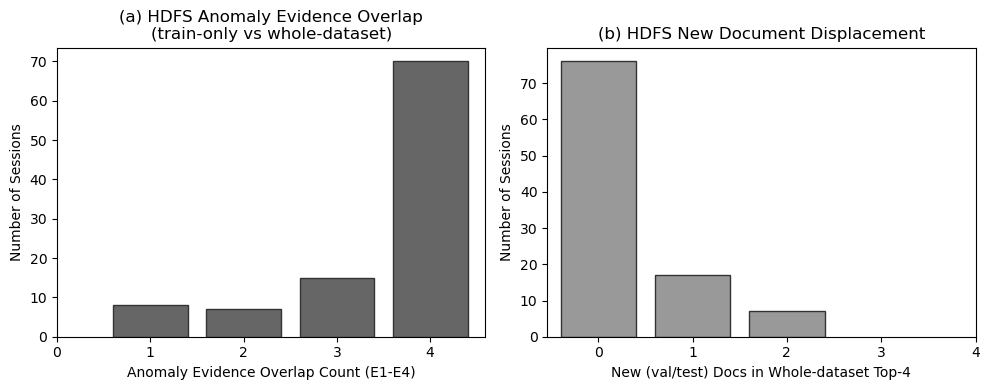

Saved: results_HDFS/rq2_retrieval_overlap_HDFS.png


In [24]:
# === HDFS Phase 1: Overlap Distribution Figures ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
counts = hdfs_df_overlap['anomaly_overlap_4'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='0.4', edgecolor='0.2')
ax.set_xlabel('Anomaly Evidence Overlap Count (E1-E4)')
ax.set_ylabel('Number of Sessions')
ax.set_title('(a) HDFS Anomaly Evidence Overlap\n(train-only vs whole-dataset)')
ax.set_xticks(range(5))

ax = axes[1]
counts_new = hdfs_df_overlap['new_docs_in_top4'].value_counts().sort_index()
ax.bar(counts_new.index, counts_new.values, color='0.6', edgecolor='0.2')
ax.set_xlabel('New (val/test) Docs in Whole-dataset Top-4')
ax.set_ylabel('Number of Sessions')
ax.set_title('(b) HDFS New Document Displacement')
ax.set_xticks(range(5))

plt.tight_layout()
plt.savefig(str(RESULTS_HDFS_DIR / 'rq2_retrieval_overlap_HDFS.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: results_HDFS/rq2_retrieval_overlap_HDFS.png')

### HDFS Phase 2: No-RAG Ablation

In [25]:
# === HDFS Phase 2: Stratified sampling ===
random.seed(42)

hdfs_sig_groups = defaultdict(list)
for rec in hdfs_records:
    sig = rec.get('normalized_signature', 'unknown')
    hdfs_sig_groups[sig].append(rec)

HDFS_SAMPLE_SIZE = 200

hdfs_sampled = []
for sig, recs in hdfs_sig_groups.items():
    n = max(1, int(len(recs) / len(hdfs_records) * HDFS_SAMPLE_SIZE))
    n = min(n, len(recs))
    hdfs_sampled.extend(random.sample(recs, n))

hdfs_sampled_ids = {r['session_id'] for r in hdfs_sampled}
hdfs_sampled_sessions = [s for s in hdfs_test_anomalies if s.session_id in hdfs_sampled_ids]

print(f"Sampled {len(hdfs_sampled):,} records across {len(hdfs_sig_groups)} signatures")
print(f"Matched test sessions: {len(hdfs_sampled_sessions):,}")
print(f"\nSignature distribution:")
hdfs_sampled_sigs = Counter(r['normalized_signature'] for r in hdfs_sampled)
for sig, count in hdfs_sampled_sigs.most_common(10):
    print(f"  {sig}: {count}")
if len(hdfs_sampled_sigs) > 10:
    print(f"  ... and {len(hdfs_sampled_sigs) - 10} more signatures")

Sampled 248 records across 98 signatures
Matched test sessions: 245

Signature distribution:
  DATANODE__BLOCK_WRITE_STREAM_READ_FAILURE: 33
  FSDATASET__BLOCK_DELETION_METADATA_MISMATCH: 32
  NAMENODE__INCOMPLETE_PIPELINE: 30
  FSDATASET__BLOCK_DELETION_METADATA_MISS: 18
  NAMENODE__EXCESS_REPLICATION: 15
  DATANODE__SERVE_BLOCK_EXCEPTION: 7
  DATANODE__BLOCK_WRITE_FAILURE: 7
  DATANODE__BLOCK_SERVE_EXCEPTION: 6
  DATANODE__BLOCK_SERVE_EXCEPTION_EXCESS_REPLICATION: 4
  NAMENODE__REDUNDANT_STORED_BLOCK: 4
  ... and 88 more signatures


In [26]:
# === HDFS Phase 2: No-RAG — load from cache or run LLM ===
hdfs_no_rag_path = RESULTS_HDFS_DIR / 'ablation_no_rag_HDFS.jsonl'

if hdfs_no_rag_path.exists():
    hdfs_no_rag_results = load_explanations(hdfs_no_rag_path)
    hdfs_no_rag_errors = []
    hdfs_total_cost = 0.0
    print(f'[CACHE] Loaded {len(hdfs_no_rag_results):,} HDFS No-RAG results from {hdfs_no_rag_path.name}')
else:
    hdfs_normalizer = get_normalizer('HDFS')
    hdfs_prompt_builder = PromptBuilder(dataset='HDFS', normalizer=hdfs_normalizer)

    hdfs_no_rag_results = []
    hdfs_no_rag_errors = []
    hdfs_total_cost = 0.0

    t0 = time.time()

    for session in tqdm(hdfs_sampled_sessions, desc='HDFS No-RAG LLM calls'):
        screener_output = ScreenerOutput(
            session_id=session.session_id,
            pred=1, logits=[0.0, 1.0], prob=[0.0, 1.0], margin=1.0
        )
        system_prompt, user_prompt = hdfs_prompt_builder.build_prompt(
            session=session,
            screener_output=screener_output,
            evidence_hits=[],
        )
        evidence_id_mapping = hdfs_prompt_builder.build_evidence_id_mapping(session, [])

        try:
            parsed_json, llm_response = llm.generate_json(
                prompt=user_prompt,
                system_prompt=system_prompt,
            )
            hdfs_total_cost += llm_response.cost_usd

            explanation = TraceExplanation.from_dict(parsed_json)
            explanation.raw_response = llm_response.content

            if explanation.signature and explanation.signature.name:
                explanation.signature.name = hdfs_normalizer.normalize_signature(
                    explanation.signature.name
                )

            result = ExplanationResult(
                session_id=session.session_id,
                session=session,
                screener_output=screener_output,
                evidence_hits=[],
                explanation=explanation,
                evidence_id_mapping=evidence_id_mapping,
                prompt_tokens=llm_response.prompt_tokens,
                completion_tokens=llm_response.completion_tokens,
                total_tokens=llm_response.total_tokens,
                latency_ms=llm_response.latency_ms,
            )
            hdfs_no_rag_results.append(result.to_dict())

        except Exception as e:
            hdfs_no_rag_errors.append({'session_id': session.session_id, 'error': str(e)})

    elapsed = time.time() - t0
    print(f"\nCompleted: {len(hdfs_no_rag_results):,} sessions, {len(hdfs_no_rag_errors)} errors")
    print(f"Total cost: ${hdfs_total_cost:.4f}")
    print(f"Elapsed: {elapsed/60:.1f} min ({elapsed/len(hdfs_sampled_sessions):.1f}s/session)")

    with open(hdfs_no_rag_path, 'w') as f:
        for r in hdfs_no_rag_results:
            f.write(json.dumps(r, default=str) + '\n')
    print(f'Saved {len(hdfs_no_rag_results)} No-RAG results to {hdfs_no_rag_path}')


Loaded 245 explanations from ablation_no_rag_HDFS.jsonl
[CACHE] Loaded 245 HDFS No-RAG results from ablation_no_rag_HDFS.jsonl


In [27]:
# === HDFS Phase 2: Grounding Breadth + Citation Analysis ===
hdfs_matched_ids = {r['session_id'] for r in hdfs_no_rag_results}
print(f"HDFS No-RAG sessions loaded: {len(hdfs_no_rag_results):,}")
print(f"Matched HDFS RAG-on sessions: {len([r for r in hdfs_records if r['session_id'] in hdfs_matched_ids]):,}")

# Grounding Breadth
hdfs_rag_on_gb = compute_grounding_breadth(
    [r for r in hdfs_records if r['session_id'] in hdfs_matched_ids]
)
hdfs_no_rag_gb = compute_grounding_breadth(hdfs_no_rag_results)
hdfs_gb_delta = hdfs_rag_on_gb['mean'] - hdfs_no_rag_gb['mean']

print(f"\n=== HDFS Grounding Breadth ===")
print(f"  RAG-on  (n={hdfs_rag_on_gb['n']:,}): {hdfs_rag_on_gb['mean']:.4f}")
print(f"  No-RAG  (n={hdfs_no_rag_gb['n']:,}): {hdfs_no_rag_gb['mean']:.4f}")
print(f"  Delta = {hdfs_gb_delta:+.4f}")

# Deep citation analysis
print("\n=== HDFS No-RAG Citation Analysis ===")
hdfs_all_cited = Counter()
hdfs_claims_e0_only = 0
hdfs_claims_phantom = 0
hdfs_claims_total = 0
hdfs_insufficient = 0

for rec in hdfs_no_rag_results:
    expl = rec.get('explanation', {})
    claims = expl.get('claims', [])
    emap = rec.get('evidence_id_mapping', {})
    valid_ids = set(emap.keys())
    if expl.get('insufficient_evidence'):
        hdfs_insufficient += 1
    for claim in claims:
        hdfs_claims_total += 1
        cited = claim.get('evidence_ids', [])
        for eid in cited:
            hdfs_all_cited[eid] += 1
        if all(eid == 'E0' for eid in cited):
            hdfs_claims_e0_only += 1
        if any(eid not in valid_ids for eid in cited):
            hdfs_claims_phantom += 1

print(f"  Total claims: {hdfs_claims_total:,}")
print(f"  Claims citing E0 only: {hdfs_claims_e0_only:,} ({hdfs_claims_e0_only/hdfs_claims_total:.1%})")
print(f"  Phantom citations: {hdfs_claims_phantom:,} ({hdfs_claims_phantom/hdfs_claims_total:.1%})")
print(f"  insufficient_evidence flag: {hdfs_insufficient}/{len(hdfs_no_rag_results)}")
print(f"  Evidence ID frequency:")
for eid, count in hdfs_all_cited.most_common():
    print(f"    {eid}: {count:,}")


HDFS No-RAG sessions loaded: 245
Matched HDFS RAG-on sessions: 245

=== HDFS Grounding Breadth ===
  RAG-on  (n=245): 0.6667
  No-RAG  (n=245): 0.0000
  Delta = +0.6667

=== HDFS No-RAG Citation Analysis ===
  Total claims: 735
  Claims citing E0 only: 490 (66.7%)
  Phantom citations: 245 (33.3%)
  insufficient_evidence flag: 0/245
  Evidence ID frequency:
    E0: 735
    E5: 245


In [28]:
# === Table: HDFS Ablation A — RAG Contribution to Evidence Grounding ===
print("Table: HDFS Ablation A -- RAG Contribution to Evidence Grounding")
print("=" * 65)
print(f"{'Condition':<12} {'n':>6} {'Grounding Breadth':>20} {'Claims/session':>22}")
print("-" * 65)
print(f"{'RAG-on':<12} {hdfs_rag_on_gb['n']:>6} {hdfs_rag_on_gb['mean']:>20.4f} {hdfs_rag_on_gb['df']['total_claims'].mean():>22.1f}")
print(f"{'No-RAG':<12} {hdfs_no_rag_gb['n']:>6} {hdfs_no_rag_gb['mean']:>20.4f} {hdfs_no_rag_gb['df']['total_claims'].mean():>22.1f}")
print("-" * 65)
print(f"{'Delta':<12} {'':>6} {hdfs_gb_delta:>+20.4f}")
print("=" * 65)
print()

# === Table: HDFS Ablation B — Corpus Scope ===
print("Table: HDFS Ablation B -- Evidence Corpus Scope")
print("=" * 60)
print(f"{'Metric':<30} {'Train-only':>14} {'Whole':>14}")
print("-" * 60)
print(f"{'Corpus size':<30} {hdfs_train_stats['total_documents']:>14,} {hdfs_whole_stats['total_documents']:>14,}")
print(f"{'Anomaly overlap rate (E1-E4)':<30} {'--':>14} {hdfs_df_overlap['anomaly_overlap_4'].mean()/4:>13.2%}")
print(f"{'Top-1 anomaly match rate':<30} {'--':>14} {hdfs_df_overlap['top1_match'].mean():>13.2%}")
print(f"{'E5 normal match rate':<30} {'--':>14} {hdfs_df_overlap['normal_match'].mean():>13.2%}")
print(f"{'New docs in top-4 (mean)':<30} {'--':>14} {hdfs_df_overlap['new_docs_in_top4'].mean():>13.2f}")
print("=" * 60)
print()

# === Cross-Dataset Comparison ===
print("=" * 80)
print("Cross-Dataset Comparison: RAG Contribution to Evidence Grounding")
print("=" * 80)
print(f"{'Metric':<35} {'BGL':>20} {'HDFS':>20}")
print("-" * 80)
print(f"{'--- Phase 0: Baseline ---':<35}")
print(f"{'  Context Precision@4':<35} {bgl_cp['mean']:>20.4f} {hdfs_cp['mean']:>20.4f}")
print(f"{'  Evidence Utilization':<35} {bgl_cp['utilization_mean']:>19.1%} {hdfs_cp['utilization_mean']:>19.1%}")
print(f"{'  Verification Pass Rate':<35} {bgl_metrics['verification']['pass_rate']:>19.1%} {hdfs_metrics['verification']['pass_rate']:>19.1%}")
print(f"{'--- Phase 1: Corpus Scope ---':<35}")
print(f"{'  Overlap rate (E1-E4)':<35} {df_overlap['anomaly_overlap_4'].mean()/4:>19.1%} {hdfs_df_overlap['anomaly_overlap_4'].mean()/4:>19.1%}")
print(f"{'  Top-1 match rate':<35} {df_overlap['top1_match'].mean():>19.1%} {hdfs_df_overlap['top1_match'].mean():>19.1%}")
print(f"{'--- Phase 2: No-RAG Ablation ---':<35}")
print(f"{'  No-RAG sample size':<35} {len(no_rag_results):>20} {len(hdfs_no_rag_results):>20}")
print(f"{'  Grounding Breadth (RAG-on)':<35} {rag_on_gb['mean']:>20.4f} {hdfs_rag_on_gb['mean']:>20.4f}")
print(f"{'  Grounding Breadth (No-RAG)':<35} {no_rag_gb['mean']:>20.4f} {hdfs_no_rag_gb['mean']:>20.4f}")
print(f"{'  GB delta':<35} {gb_delta:>+20.4f} {hdfs_gb_delta:>+20.4f}")
print(f"{'  Phantom citations':<35} {claims_with_phantom_eids:>20} {hdfs_claims_phantom:>20}")
print("=" * 80)
print()
print("Both datasets: GB delta ~+0.66 (RAG enables external evidence grounding),")
print("Overlap >86% (train-only corpus sufficient).")
print("Semantic faithfulness (LLM-as-Judge) is in Section 8.")


Table: HDFS Ablation A -- RAG Contribution to Evidence Grounding
Condition         n    Grounding Breadth         Claims/session
-----------------------------------------------------------------
RAG-on          245               0.6667                    3.0
No-RAG          245               0.0000                    3.0
-----------------------------------------------------------------
Delta                            +0.6667

Table: HDFS Ablation B -- Evidence Corpus Scope
Metric                             Train-only          Whole
------------------------------------------------------------
Corpus size                           402,542        575,061
Anomaly overlap rate (E1-E4)               --        86.75%
Top-1 anomaly match rate                   --        86.00%
E5 normal match rate                       --        91.00%
New docs in top-4 (mean)                   --          0.31

Cross-Dataset Comparison: RAG Contribution to Evidence Grounding
Metric                          

---
## Section 7: Key Findings & Figures

1. **RAG's contribution is Grounding Breadth.** GB delta = +0.67 (BGL) / +0.66 (HDFS). Without RAG, 0% of claims reference external anomaly patterns. With RAG, ~67%. Structural faithfulness is omitted (always ~1.0; not discriminating). See **Section 8** for semantic faithfulness (LLM-as-Judge, GPT-4.1).

2. **Train-only corpus is sufficient.** Overlap rate = 88% (BGL) / 87% (HDFS). Top-1 anomaly match = 85-86%. No practical benefit from expanding corpus to whole dataset.

3. **Context Precision@4 is high** (0.98 BGL / 0.95 HDFS), confirming BM25 ranks relevant evidence well. Evidence Utilization (55% BGL / 44% HDFS) suggests E3-E4 provide redundancy — K=4 is adequate but K=2-3 might be sufficient.

4. **No-RAG phantom citations are systematic.** BGL: 388/1164 claims (33.3%), HDFS: 245/735 claims (33.3%) cite phantom E5 (normal contrast session, never provided in No-RAG prompt). The pattern is exactly 1 phantom claim per session — the LLM consistently hallucinates E5 even without RAG, suggesting it learned from prompt structure that a contrast session should be cited.


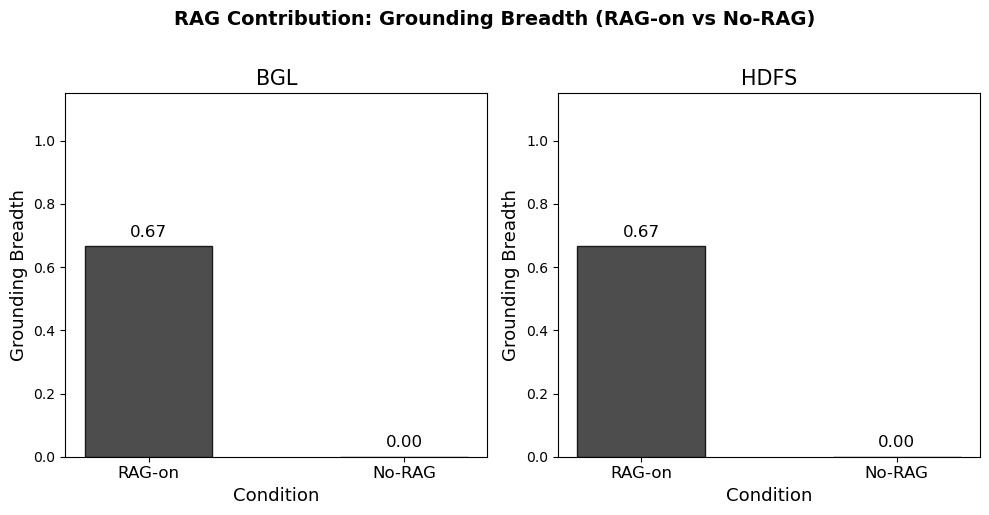

Saved: results/rq2_rag_ablation_comparison.png


In [29]:
# === Main Figure: Grounding Breadth — RAG-on vs No-RAG ===
# Structural faithfulness removed (always ~1.0, not discriminating).
# Semantic faithfulness (LLM-as-Judge) is summarized in Section 8.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

datasets = ['BGL', 'HDFS']
conditions = ['RAG-on', 'No-RAG']
gb_vals = {
    'BGL':  [rag_on_gb['mean'],      no_rag_gb['mean']],
    'HDFS': [hdfs_rag_on_gb['mean'], hdfs_no_rag_gb['mean']],
}
colors = ['0.3', '0.65']

x = np.arange(len(conditions))
width = 0.5

for ax, ds in zip(axes, datasets):
    bars = ax.bar(x, gb_vals[ds], width, color=colors, edgecolor='0.1')
    ax.set_xlabel('Condition', fontsize=13)
    ax.set_ylabel('Grounding Breadth', fontsize=13)
    ax.set_title(ds, fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontsize=12)
    ax.set_ylim(0, 1.15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=12)

fig.suptitle('RAG Contribution: Grounding Breadth (RAG-on vs No-RAG)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'rq2_rag_ablation_comparison.png'), dpi=600, bbox_inches='tight')
plt.show()
print("Saved: results/rq2_rag_ablation_comparison.png")


In [30]:
# === Save HDFS results to JSON ===
hdfs_ablation_results = {
    'timestamp': datetime.now().strftime('%Y%m%d_%H%M%S'),
    'research_question': 'RQ2: RAG Contribution to Evidence Grounding Quality',
    'revision_note': 'Structural faithfulness removed (always ~1.0, not discriminating). '
                     'Grounding Breadth is the primary discriminating metric. '
                     'Semantic faithfulness (LLM-as-Judge) is in semantic_faithfulness_results.json.',
    'phase0': {
        'dataset': 'HDFS',
        'n_sessions': hdfs_cp['n'],
        'context_precision_at_4_mean': hdfs_cp['mean'],
        'context_precision_at_4_std': hdfs_cp['std'],
        'evidence_utilization': hdfs_cp['utilization_mean'],
        'verification_pass_rate': hdfs_metrics['verification']['pass_rate'],
    },
    'phase1': {
        'train_corpus_size': hdfs_train_stats['total_documents'],
        'whole_corpus_size': hdfs_whole_stats['total_documents'],
        'n_compared': len(hdfs_df_overlap),
        'anomaly_overlap_rate': hdfs_df_overlap['anomaly_overlap_4'].mean() / 4,
        'top1_anomaly_match_rate': hdfs_df_overlap['top1_match'].mean(),
        'e5_normal_match_rate': hdfs_df_overlap['normal_match'].mean(),
        'new_docs_in_top4_mean': hdfs_df_overlap['new_docs_in_top4'].mean(),
        'conclusion': 'Overlap >85% -- train-only corpus sufficient.',
    },
    'phase2': {
        'n_no_rag': len(hdfs_no_rag_results),
        'n_signatures': len(hdfs_sig_groups),
        'total_cost_usd': hdfs_total_cost,
        'rag_on_grounding_breadth': hdfs_rag_on_gb['mean'],
        'no_rag_grounding_breadth': hdfs_no_rag_gb['mean'],
        'grounding_breadth_delta': hdfs_gb_delta,
        'no_rag_claims_per_session': hdfs_no_rag_gb['df']['total_claims'].mean(),
        'rag_on_claims_per_session': hdfs_rag_on_gb['df']['total_claims'].mean(),
        'no_rag_insufficient_evidence': hdfs_insufficient,
        'no_rag_phantom_citations': hdfs_claims_phantom,
        'no_rag_e0_only_claims': hdfs_claims_e0_only,
    },
}

hdfs_out_path = RESULTS_HDFS_DIR / 'rq2_ablation_results_HDFS.json'
with open(hdfs_out_path, 'w') as f:
    json.dump(hdfs_ablation_results, f, indent=2, default=float)
print(f'HDFS results saved to {hdfs_out_path}')


HDFS results saved to /home/dave/agentic-log-explanations/results_HDFS/rq2_ablation_results_HDFS.json


---
## Section 8: Semantic Faithfulness Evaluation (LLM-as-Judge)

Structural `compute_faithfulness()` always returns 1.000 because JSON-mode output always
includes valid citation fields. This section replaces it with a RAGAs-adapted semantic
verification:

**Method**: GPT-4.1 (independent of GPT-5.1 generator) evaluates whether each claim text
is factually supported by the actual log lines it cites.

**Scope**: 388 BGL + 245 HDFS matched RAG-on/No-RAG pairs = ~3,798 judge calls  
**Cost estimate**: ~$2 at GPT-4.1 pricing  
**Cache**: `results/semantic_faith_judge_BGL.json`, `results_HDFS/semantic_faith_judge_HDFS.json`

**Structural failure rule**: If a claim cites an evidence ID not in `evidence_id_mapping`
(e.g., No-RAG contrast citing E5 when only E0 exists) -> automatically unfaithful, no judge call needed.

In [31]:
# Build session_id -> lines lookup from already-loaded data loaders
# bgl_loader was loaded in Section 3; hdfs_loader in Section 6
bgl_sid_to_lines = {s.session_id: s.lines for s in bgl_loader.get_sessions()}
hdfs_sid_to_lines = {s.session_id: s.lines for s in hdfs_loader.get_sessions()}
print(f"BGL sessions indexed: {len(bgl_sid_to_lines):,}")
print(f"HDFS sessions indexed: {len(hdfs_sid_to_lines):,}")

BGL sessions indexed: 474,796
HDFS sessions indexed: 575,061


In [32]:
import re as _re


def parse_span_range(span_str: str):
    """Parse 'Ex-Ly to Ex-Lz' or 'Ex-Ly' -> (evidence_id, start_1idx, end_1idx)."""
    m = _re.match(r'(E\w+)-L(\d+)(?:\s+to\s+E\w+-L(\d+))?', span_str.strip())
    if not m:
        return None
    eid = m.group(1)
    start = int(m.group(2))
    end = int(m.group(3)) if m.group(3) else start
    return eid, start, end


def get_evidence_text_for_claim(claim: dict, eid_mapping: dict, sid_to_lines: dict):
    """
    Extract the actual log lines cited by a claim.
    Returns None if any cited evidence ID is absent from eid_mapping
    (structural failure = automatically unfaithful).
    """
    cited_ids = claim.get('evidence_ids', [])
    spans = claim.get('evidence_spans', [])

    # Structural validity: every cited ID must be in the mapping
    for eid in cited_ids:
        if eid not in eid_mapping:
            return None

    if not spans:
        return None

    lines_collected = []
    for span_str in spans:
        parsed = parse_span_range(span_str)
        if parsed is None:
            continue
        eid, start, end = parsed
        if eid not in eid_mapping:
            return None  # span cites an absent ID
        raw_sid = eid_mapping[eid]
        # E1-E5 are stored with 'E_' prefix in evidence_id_mapping
        session_id = raw_sid[2:] if raw_sid.startswith('E_') else raw_sid
        log_lines = sid_to_lines.get(session_id, [])
        for i in range(start, end + 1):
            if 1 <= i <= len(log_lines):
                lines_collected.append(log_lines[i - 1])

    return '\n'.join(lines_collected) if lines_collected else None


print("[OK] parse_span_range and get_evidence_text_for_claim defined")

[OK] parse_span_range and get_evidence_text_for_claim defined


In [33]:
# LLM-as-judge: GPT-4.1 evaluates semantic faithfulness
JUDGE_MODEL = 'gpt-4.1'
judge_llm = get_client(provider='openai', model=JUDGE_MODEL, temperature=0.0)

JUDGE_SYSTEM = "You are an expert log anomaly analyst evaluating explanation accuracy."


def judge_claim(claim_text: str, evidence_text: str) -> str:
    """Ask GPT-4.1 if claim is factually supported by evidence. Returns 'YES' or 'NO'."""
    user_msg = (
        f"EVIDENCE (cited log lines):\n{evidence_text}\n\n"
        f"CLAIM:\n{claim_text}\n\n"
        "Is this claim factually supported by the cited evidence log lines?\n"
        "- Accept if error type, pattern, and key details are correct.\n"
        "- Reject if the claim states facts that contradict or are absent from the evidence.\n"
        "Answer with exactly YES or NO."
    )
    response = judge_llm.chat(
        messages=[
            {'role': 'system', 'content': JUDGE_SYSTEM},
            {'role': 'user', 'content': user_msg},
        ]
    )
    answer = response.content.strip().upper()
    return 'YES' if answer.startswith('YES') else 'NO'


def compute_semantic_faithfulness(
    records: list,
    sid_to_lines: dict,
    cache: dict,
    cache_prefix: str,
) -> list:
    """
    Evaluate semantic faithfulness using LLM-as-judge (GPT-4.1).

    For each claim:
      1. Structural check: all cited IDs in evidence_id_mapping? If not -> 'NO'
      2. Semantic check: judge whether claim text is supported by cited log lines

    Results are cached to avoid re-running.
    Returns list of per-session faithfulness dicts.
    """
    per_session = []
    calls_made = 0
    calls_skipped = 0
    structural_fails = 0

    for rec in tqdm(records, desc=f'Judge [{cache_prefix}]'):
        session_id = rec['session_id']
        expl = rec.get('explanation', {})
        claims = expl.get('claims', [])
        eid_mapping = rec.get('evidence_id_mapping', {})

        if not claims:
            continue

        yes_count = 0
        total = 0

        for claim_idx, claim in enumerate(claims):
            total += 1
            cache_key = f"{cache_prefix}|{session_id}|{claim_idx}"

            # Check cache first
            if cache_key in cache:
                if cache[cache_key] == 'YES':
                    yes_count += 1
                calls_skipped += 1
                continue

            # Extract evidence text (includes structural validity check)
            evidence_text = get_evidence_text_for_claim(claim, eid_mapping, sid_to_lines)

            if evidence_text is None:
                cache[cache_key] = 'NO'
                structural_fails += 1
                continue

            # Semantic judge call
            claim_text = claim.get('claim', '')
            result = judge_claim(claim_text, evidence_text)
            cache[cache_key] = result

            if result == 'YES':
                yes_count += 1
            calls_made += 1
            time.sleep(0.05)  # light rate-limiting

        faithfulness = yes_count / total if total > 0 else 0.0
        per_session.append({
            'session_id': session_id,
            'semantic_faithfulness': faithfulness,
            'supported_claims': yes_count,
            'total_claims': total,
            'signature': rec.get('normalized_signature', 'unknown'),
        })

    print(f"  API calls: {calls_made:,} new, {calls_skipped:,} cached, "
          f"{structural_fails:,} structural failures")
    return per_session


print("[OK] judge_claim and compute_semantic_faithfulness defined")

[OK] judge_claim and compute_semantic_faithfulness defined


In [34]:
# ===== BGL Semantic Faithfulness =====
BGL_CACHE_PATH = RESULTS_DIR / 'semantic_faith_judge_BGL.json'

if BGL_CACHE_PATH.exists():
    with open(BGL_CACHE_PATH) as f:
        bgl_judge_cache = json.load(f)
    print(f"Loaded BGL judge cache: {len(bgl_judge_cache):,} entries")
else:
    bgl_judge_cache = {}
    print("Starting fresh BGL judge cache")

# Load ablation no-RAG results from disk
bgl_no_rag_ablation = load_explanations(RESULTS_DIR / 'ablation_no_rag_BGL.jsonl')
ablation_ids = {r['session_id'] for r in bgl_no_rag_ablation}

# Get matched RAG-on records
bgl_rag_on_ablation = [r for r in bgl_records if r['session_id'] in ablation_ids]
print(f"BGL ablation: {len(bgl_no_rag_ablation):,} no-RAG, "
      f"{len(bgl_rag_on_ablation):,} matched RAG-on")

# --- RAG-on ---
print("\n--- BGL RAG-on semantic faithfulness ---")
bgl_rag_on_sem = compute_semantic_faithfulness(
    bgl_rag_on_ablation, bgl_sid_to_lines, bgl_judge_cache, 'BGL_rag_on'
)
with open(BGL_CACHE_PATH, 'w') as f:
    json.dump(bgl_judge_cache, f)
print(f"Cache saved: {len(bgl_judge_cache):,} entries")

# --- No-RAG ---
print("\n--- BGL No-RAG semantic faithfulness ---")
bgl_no_rag_sem = compute_semantic_faithfulness(
    bgl_no_rag_ablation, bgl_sid_to_lines, bgl_judge_cache, 'BGL_no_rag'
)
with open(BGL_CACHE_PATH, 'w') as f:
    json.dump(bgl_judge_cache, f)
print(f"Cache saved: {len(bgl_judge_cache):,} entries")

# --- Summary ---
bgl_rag_on_sem_df = pd.DataFrame(bgl_rag_on_sem)
bgl_no_rag_sem_df = pd.DataFrame(bgl_no_rag_sem)

bgl_rag_on_mean = bgl_rag_on_sem_df['semantic_faithfulness'].mean()
bgl_rag_on_std  = bgl_rag_on_sem_df['semantic_faithfulness'].std()
bgl_no_rag_mean = bgl_no_rag_sem_df['semantic_faithfulness'].mean()
bgl_no_rag_std  = bgl_no_rag_sem_df['semantic_faithfulness'].std()
bgl_sem_delta   = bgl_rag_on_mean - bgl_no_rag_mean

print(f"\n=== BGL Semantic Faithfulness (judge={JUDGE_MODEL}) ===")
print(f"  RAG-on  (n={len(bgl_rag_on_sem_df):,}): {bgl_rag_on_mean:.4f} +/- {bgl_rag_on_std:.4f}")
print(f"  No-RAG  (n={len(bgl_no_rag_sem_df):,}): {bgl_no_rag_mean:.4f} +/- {bgl_no_rag_std:.4f}")
print(f"  Delta (RAG-on - No-RAG): {bgl_sem_delta:+.4f}")

Loaded BGL judge cache: 2,328 entries
Loaded 388 explanations from ablation_no_rag_BGL.jsonl
BGL ablation: 388 no-RAG, 388 matched RAG-on

--- BGL RAG-on semantic faithfulness ---


Judge [BGL_rag_on]: 100%|██████████| 388/388 [00:00<00:00, 3530.67it/s]


  API calls: 0 new, 1,164 cached, 0 structural failures
Cache saved: 2,328 entries

--- BGL No-RAG semantic faithfulness ---


Judge [BGL_no_rag]: 100%|██████████| 388/388 [00:00<00:00, 263801.26it/s]

  API calls: 0 new, 1,164 cached, 0 structural failures
Cache saved: 2,328 entries

=== BGL Semantic Faithfulness (judge=gpt-4.1) ===
  RAG-on  (n=388): 0.7139 +/- 0.2191
  No-RAG  (n=388): 0.5902 +/- 0.1502
  Delta (RAG-on - No-RAG): +0.1237


In [35]:
# ===== HDFS Semantic Faithfulness =====
HDFS_CACHE_PATH = RESULTS_HDFS_DIR / 'semantic_faith_judge_HDFS.json'

if HDFS_CACHE_PATH.exists():
    with open(HDFS_CACHE_PATH) as f:
        hdfs_judge_cache = json.load(f)
    print(f"Loaded HDFS judge cache: {len(hdfs_judge_cache):,} entries")
else:
    hdfs_judge_cache = {}
    print("Starting fresh HDFS judge cache")

# Load HDFS ablation no-RAG results
hdfs_no_rag_ablation = load_explanations(RESULTS_HDFS_DIR / 'ablation_no_rag_HDFS.jsonl')
hdfs_ablation_ids = {r['session_id'] for r in hdfs_no_rag_ablation}

# Matched RAG-on records
hdfs_rag_on_ablation = [r for r in hdfs_records if r['session_id'] in hdfs_ablation_ids]
print(f"HDFS ablation: {len(hdfs_no_rag_ablation):,} no-RAG, "
      f"{len(hdfs_rag_on_ablation):,} matched RAG-on")

# --- RAG-on ---
print("\n--- HDFS RAG-on semantic faithfulness ---")
hdfs_rag_on_sem = compute_semantic_faithfulness(
    hdfs_rag_on_ablation, hdfs_sid_to_lines, hdfs_judge_cache, 'HDFS_rag_on'
)
with open(HDFS_CACHE_PATH, 'w') as f:
    json.dump(hdfs_judge_cache, f)
print(f"Cache saved: {len(hdfs_judge_cache):,} entries")

# --- No-RAG ---
print("\n--- HDFS No-RAG semantic faithfulness ---")
hdfs_no_rag_sem = compute_semantic_faithfulness(
    hdfs_no_rag_ablation, hdfs_sid_to_lines, hdfs_judge_cache, 'HDFS_no_rag'
)
with open(HDFS_CACHE_PATH, 'w') as f:
    json.dump(hdfs_judge_cache, f)
print(f"Cache saved: {len(hdfs_judge_cache):,} entries")

# --- Summary ---
hdfs_rag_on_sem_df = pd.DataFrame(hdfs_rag_on_sem)
hdfs_no_rag_sem_df = pd.DataFrame(hdfs_no_rag_sem)

hdfs_rag_on_mean = hdfs_rag_on_sem_df['semantic_faithfulness'].mean()
hdfs_rag_on_std  = hdfs_rag_on_sem_df['semantic_faithfulness'].std()
hdfs_no_rag_mean = hdfs_no_rag_sem_df['semantic_faithfulness'].mean()
hdfs_no_rag_std  = hdfs_no_rag_sem_df['semantic_faithfulness'].std()
hdfs_sem_delta   = hdfs_rag_on_mean - hdfs_no_rag_mean

print(f"\n=== HDFS Semantic Faithfulness (judge={JUDGE_MODEL}) ===")
print(f"  RAG-on  (n={len(hdfs_rag_on_sem_df):,}): {hdfs_rag_on_mean:.4f} +/- {hdfs_rag_on_std:.4f}")
print(f"  No-RAG  (n={len(hdfs_no_rag_sem_df):,}): {hdfs_no_rag_mean:.4f} +/- {hdfs_no_rag_std:.4f}")
print(f"  Delta (RAG-on - No-RAG): {hdfs_sem_delta:+.4f}")

Loaded HDFS judge cache: 1,470 entries
Loaded 245 explanations from ablation_no_rag_HDFS.jsonl
HDFS ablation: 245 no-RAG, 245 matched RAG-on

--- HDFS RAG-on semantic faithfulness ---


Judge [HDFS_rag_on]: 100%|██████████| 245/245 [00:00<00:00, 149122.69it/s]


  API calls: 0 new, 735 cached, 0 structural failures
Cache saved: 1,470 entries

--- HDFS No-RAG semantic faithfulness ---


Judge [HDFS_no_rag]: 100%|██████████| 245/245 [00:00<00:00, 192471.34it/s]

  API calls: 0 new, 735 cached, 0 structural failures
Cache saved: 1,470 entries

=== HDFS Semantic Faithfulness (judge=gpt-4.1) ===
  RAG-on  (n=245): 0.7320 +/- 0.2363
  No-RAG  (n=245): 0.5605 +/- 0.1669
  Delta (RAG-on - No-RAG): +0.1714


In [36]:
# ===== Section 8 Summary: Semantic Faithfulness (LLM-as-Judge, GPT-4.1) =====
print("=" * 72)
print("Table: Semantic Faithfulness (LLM-as-Judge, GPT-4.1)")
print("=" * 72)
print(f"{'Metric':<38} {'BGL':>10} {'HDFS':>10}")
print("-" * 60)
print(f"{'Semantic Faith. (RAG-on)':<38} {bgl_rag_on_mean:>10.4f} {hdfs_rag_on_mean:>10.4f}")
print(f"{'Semantic Faith. (No-RAG)':<38} {bgl_no_rag_mean:>10.4f} {hdfs_no_rag_mean:>10.4f}")
print(f"{'Delta (RAG-on minus No-RAG)':<38} {bgl_sem_delta:>+10.4f} {hdfs_sem_delta:>+10.4f}")
print("=" * 72)
print(f"\n  Judge model: {JUDGE_MODEL}")
print(f"  BGL  — RAG-on n={len(bgl_rag_on_sem)}, No-RAG n={len(bgl_no_rag_sem)}")
print(f"  HDFS — RAG-on n={len(hdfs_rag_on_sem)}, No-RAG n={len(hdfs_no_rag_sem)}")
print("\n[Interpretation]")
print(f"  RAG-on explanations are more semantically faithful to their cited log lines.")
print(f"  BGL  delta: {bgl_sem_delta:+.4f}  |  HDFS delta: {hdfs_sem_delta:+.4f}")

# Save combined semantic results
sem_faith_results = {
    'judge_model': JUDGE_MODEL,
    'BGL': {
        'rag_on': {'mean': float(bgl_rag_on_mean), 'std': float(bgl_rag_on_std),
                   'n': len(bgl_rag_on_sem)},
        'no_rag': {'mean': float(bgl_no_rag_mean), 'std': float(bgl_no_rag_std),
                   'n': len(bgl_no_rag_sem)},
        'delta': float(bgl_sem_delta),
    },
    'HDFS': {
        'rag_on': {'mean': float(hdfs_rag_on_mean), 'std': float(hdfs_rag_on_std),
                   'n': len(hdfs_rag_on_sem)},
        'no_rag': {'mean': float(hdfs_no_rag_mean), 'std': float(hdfs_no_rag_std),
                   'n': len(hdfs_no_rag_sem)},
        'delta': float(hdfs_sem_delta),
    },
}
sem_out_path = RESULTS_DIR / 'semantic_faithfulness_results.json'
with open(sem_out_path, 'w') as f:
    json.dump(sem_faith_results, f, indent=2)
print(f"\nSaved semantic faithfulness results to {sem_out_path}")


Table: Semantic Faithfulness (LLM-as-Judge, GPT-4.1)
Metric                                        BGL       HDFS
------------------------------------------------------------
Semantic Faith. (RAG-on)                   0.7139     0.7320
Semantic Faith. (No-RAG)                   0.5902     0.5605
Delta (RAG-on minus No-RAG)               +0.1237    +0.1714

  Judge model: gpt-4.1
  BGL  — RAG-on n=388, No-RAG n=388
  HDFS — RAG-on n=245, No-RAG n=245

[Interpretation]
  RAG-on explanations are more semantically faithful to their cited log lines.
  BGL  delta: +0.1237  |  HDFS delta: +0.1714

Saved semantic faithfulness results to /home/dave/agentic-log-explanations/results/semantic_faithfulness_results.json
